In [1]:
import numpy as np
import matplotlib.pyplot as plt


échauffement: le broadcasting

In [4]:
a=np.array([1,2,3])
print(a)

[1 2 3]


In [3]:
#1. On cherche la forme
print(a[:,None])

[[1]
 [2]
 [3]]


On a ajouté une dimension: on passe de (3,) à (3,1) en "créant" une colonne 

In [ ]:
# Puis n cherche la forme
print(a[None,:])

[[1 2 3]]


Cette fois-ci, on passe de (3,) à (1,3)

In [8]:
#2.
print(a[:,None]-a[None,:])

[[ 0 -1 -2]
 [ 1  0 -1]
 [ 2  1  0]]


On a "dupliqué" la colonne de a[:,None] pour avoir une matrice de taille 3*3, et à chacune des lignes on a enlevé la matrice ligne qui vaut a[None,:]: on a donc une forme (3,3) et l'élément [i,j] contient i-j

In [6]:
#3. je me donne un tableau b qui est de taille (2,3)
b=np.array([[1,2,3],[4,5,6]])
print(b)

[[1 2 3]
 [4 5 6]]


In [10]:
#Je décompose par étapes
print(b[:,None,:])

[[[1 2 3]]

 [[4 5 6]]]


La taille est (2,1,3)

In [11]:
print(b[:,:,None])

[[[1]
  [2]
  [3]]

 [[4]
  [5]
  [6]]]


La taille est (2,3,1)

In [16]:
c=b[:,None,:]-b[:,:,None]
print(c)

[[[ 0  1  2]
  [-1  0  1]
  [-2 -1  0]]

 [[ 0  1  2]
  [-1  0  1]
  [-2 -1  0]]]


initialisation aléatoire

In [15]:
# les bornes pour le tirage au sort initial
mass_max = 3.
    
x_min, x_max = -10., 10.
y_min, y_max = -10., 10.

speed_max = 1.


In [154]:
def init_problem(N):
    masses=np.random.uniform(0.001,mass_max,(N,))
    low=np.array([[x_min],[y_min]])
    high=np.array([[x_max],[y_max]])
    positions=np.random.uniform(low,high,(2,N))
    speeds=np.random.uniform(0,speed_max,(2,N))
    return masses,positions, speeds

In [36]:
# pour tester

# normalement vous devez pouvoir faire ceci

masses, positions, speeds = init_problem(10)

# et ceci devrait afficher OK
try:
    assert masses.shape == (10,) and positions.shape == speeds.shape == (2, 10)
    print("OK")
except:
    print("KO")

OK


initialisation reproductible

In [37]:
# for your convenience

def init3():
    # first element is sun-like: heavy, at the center, and no speed
    masses = np.array([3, 1, 1], dtype=float)
    positions = np.array([
        [0, 5, -5], 
        [0, 1, -1]], dtype=float)
    speeds = np.array([
        [0, -1, 1], 
        [0, 0, 0]], dtype=float)
    return masses, positions, speeds


In [ ]:
#Puisque l'on procède par étapes,
#je vais écrire plusieurs fonctions
#1. Les différences de vecteurs
def vecteurs(positions):
    diff=positions[:,None,:]-positions[:,:,None]
    return diff

In [ ]:
#2. Les distances entre les positions des corps à un instant donné 
def distances(positions):
    dist=np.linalg.norm(vecteurs(positions),axis=0)
    return dist

dist[i,i] renvoit évidemment 0, puisqu'il ne faut pas diviser par 0 on va le remplacer par l'infini (contribution nulle)

In [56]:
def distancesv2(positions):
    dist=np.linalg.norm(vecteurs(positions),axis=0)
    np.fill_diagonal(dist,np.inf)
    return dist  

In [ ]:
#On construit maintenant la partie du terme qui vaut le produit des 2 masses
def prod_masses(masses):
    produit=masses[:,None]*masses[None,:]
    return produit


In [ ]:
#3. #Le coefficient non vectoriel (la partie scalaire de chaque terme des sommes)
def coeff(positions,masses,G):
    return G*prod_masses(masses)/(distancesv2(positions)**3)

In [ ]:
#Le terme complet des sommes, vectorielles cette fois-ci
def coeff_final(masses,positions,G):
    return vecteurs(positions)*coeff(positions,masses,G)[None,:,:]

In [ ]:
#4. Les sommes finale
def forces(masses,positions,G=1.0):
    return np.sum(coeff_final(masses,positions,G),axis=2)

In [102]:
# pour tester, voici les valeurs attendues avec la config prédéfinie

masses, positions, speeds = init3()

f = forces(masses, positions)

# should be true
np.all(np.isclose(f, np.array([
     [ 0.        , -0.12257258,  0.12257258],
     [ 0.        , -0.02451452,  0.02451452]])))

np.True_

le simulateur

In [127]:
#cette fois-ci, on procède avec une unique fonction
def simulate(masses,positions,speeds,dt=0.1,nb_steps=100):
    dim=len(positions)
    N=len(positions[0])
    trajectoires=np.zeros((nb_steps,dim,N))
    #On initialise
    trajectoires[0]=positions
    
    for i in range(1,nb_steps):
        a=forces(masses,positions)/masses[None,:]
        speeds=speeds+a*dt
        positions=positions+speeds*dt
        trajectoires[i]=positions
    return trajectoires


In [128]:
# pour tester

SMALL_STEPS = 4

s = simulate(masses, positions, speeds, nb_steps=SMALL_STEPS)

try:
    if s.shape == (SMALL_STEPS, 2, 3):
        print("shape OK")
except Exception as exc:
    print(f"OOPS {type(exc)} {exc}")

shape OK


In [175]:
# pour tester: should be true

# first step
positions1 = s[1]

np.all(np.isclose(positions1, np.array([
     [ 0.        ,  4.89877427, -4.89877427],
    [ 0.        ,  0.99975485, -0.99975485]
 ])))

np.True_

dessiner

La question était de savoir (ce sera utile pour le code suivant) qu'est ce que renvoit simulation[:,:,i]: il renvoit une liste d'indices (x) et d'ordonnées (y) pour le i-ème corps. Cependant sa taille est (N,2) alors qu'il nous est plus simple pour la suite de manipuler qch de taille (2,N) pour ne pas avoir à écrire de boucle for 

In [ ]:
import random as rd
import matplotlib.pyplot as plt

def draw(simulation,masses,colors=None,scale=10.):
    N=len(masses)
    #On commence par affecter des couleurs si elles ne sont pas fournies
    if colors is None:
        colors=np.random.randint(0,255,(N,3))/255
    
    fig, ax= plt.subplots()
    for i in range(N):
        ax.scatter(simulation[:,:,i].T[0],simulation[:,:,i].T[1],color=colors[i],s=masses[i]*scale)
    plt.show()

In [160]:
# for convenience

colors3 = np.array([
    (32, 32, 32),
    (228, 90, 146),
    (111, 0, 255),
]) / 255

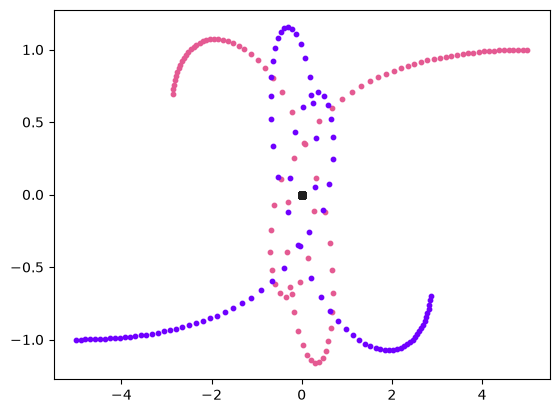

In [161]:
#On teste
draw(simulate(masses, positions, speeds), masses, colors3)


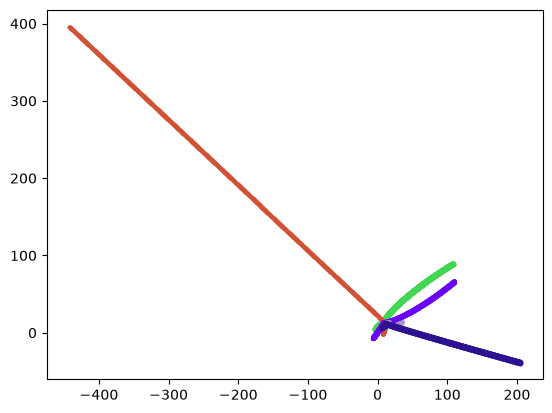

<Figure size 640x480 with 0 Axes>

In [171]:
m5, p5, s5 = init_problem(5)
sim5 = simulate(m5, p5, s5, nb_steps=1000)
draw(sim5, m5, scale=3);
plt.savefig("random5.png")